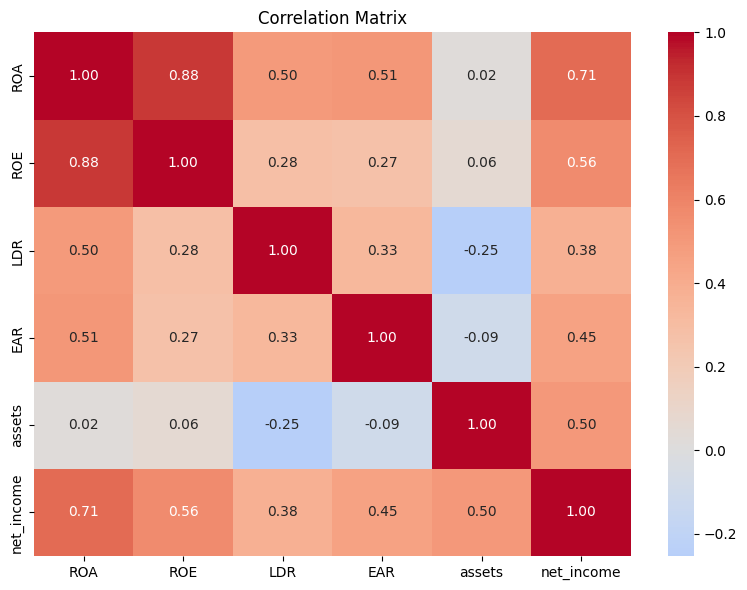

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/banks_with_ratios.csv")
df["bank_name"] = df["bank_name"].str.replace('"', '').str.strip()
df = df[df["LDR"] < 10]
df = df[df["ROE"] < 10]

metrics = ["ROA", "ROE", "LDR", "EAR", "assets", "net_income"]
corr = df[metrics].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

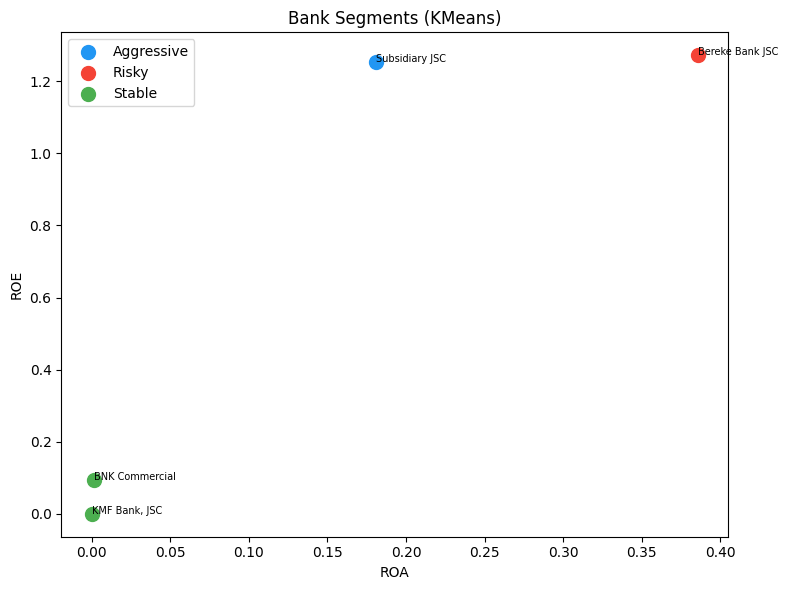

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df_cluster = df[df["year"] == 2026][["bank_name", "ROA", "ROE", "LDR", "EAR", "assets"]].dropna()

scaler = StandardScaler()
X = scaler.fit_transform(df_cluster[["ROA", "ROE", "LDR", "EAR"]])

kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster["cluster"] = kmeans.fit_predict(X)

labels = {0: "Stable", 1: "Aggressive", 2: "Risky"}
df_cluster["segment"] = df_cluster["cluster"].map(labels)

fig, ax = plt.subplots(figsize=(8, 6))
colors = {"Stable": "#4CAF50", "Aggressive": "#2196F3", "Risky": "#f44336"}
for segment, group in df_cluster.groupby("segment"):
    ax.scatter(group["ROA"], group["ROE"], label=segment, color=colors[segment], s=100)
    for _, row in group.iterrows():
        ax.annotate(row["bank_name"][:15], (row["ROA"], row["ROE"]), fontsize=7)

ax.set_xlabel("ROA")
ax.set_ylabel("ROE")
ax.set_title("Bank Segments (KMeans)")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
print(df[df["year"] == 2026][["bank_name", "ROA", "ROE", "LDR"]].to_string())

                                          bank_name           ROA       ROE       LDR
70  Bereke Bank JSC (SB of Lesha Bank LLC (Public))  3.854267e-01  1.271985  9.886433
80                                    KMF Bank, JSC  2.966178e-07  0.000025  9.715576
82             Subsidiary JSC Bank VTB (Kazakhstan)  1.809541e-01  1.252165  5.594745
85                          BNK Commercial Bank JSC  1.326295e-03  0.092842  6.355986


(31, 8)


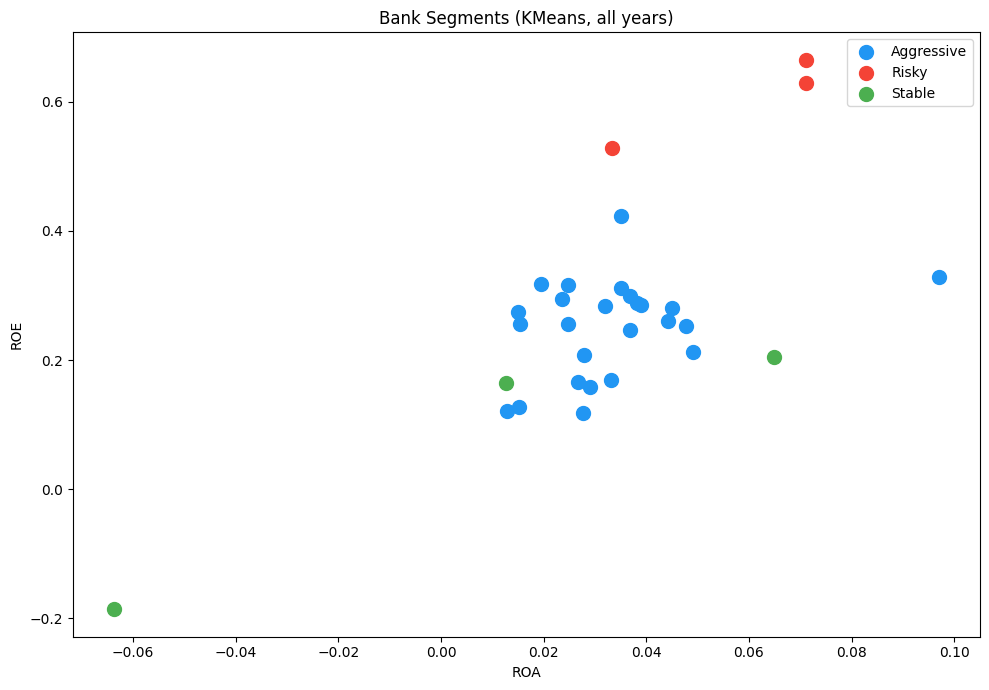

In [5]:
df_cluster = df[["bank_name", "year", "ROA", "ROE", "LDR", "EAR"]].dropna()
df_cluster = df_cluster[df_cluster["ROA"] < 0.15]
df_cluster = df_cluster[df_cluster["ROE"] < 1.0]
df_cluster = df_cluster[df_cluster["LDR"] < 5]

scaler = StandardScaler()
X = scaler.fit_transform(df_cluster[["ROA", "ROE", "LDR", "EAR"]])

kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster["cluster"] = kmeans.fit_predict(X)

labels = {0: "Stable", 1: "Aggressive", 2: "Risky"}
df_cluster["segment"] = df_cluster["cluster"].map(labels)

print(df_cluster.shape)
fig, ax = plt.subplots(figsize=(10, 7))
colors = {"Stable": "#4CAF50", "Aggressive": "#2196F3", "Risky": "#f44336"}
for segment, group in df_cluster.groupby("segment"):
    ax.scatter(group["ROA"], group["ROE"], label=segment, color=colors[segment], s=100)

ax.set_xlabel("ROA")
ax.set_ylabel("ROE")
ax.set_title("Bank Segments (KMeans, all years)")
ax.legend()
plt.tight_layout()
plt.show()